## LAB-11 k-Means Clustering Unsupervised

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

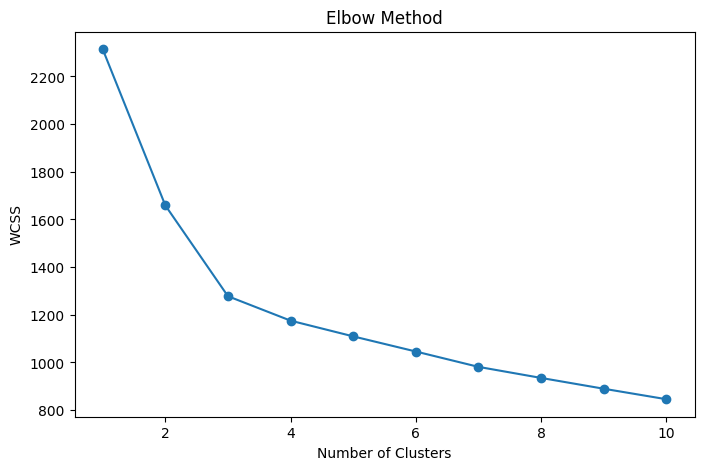

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Cluster  
0         

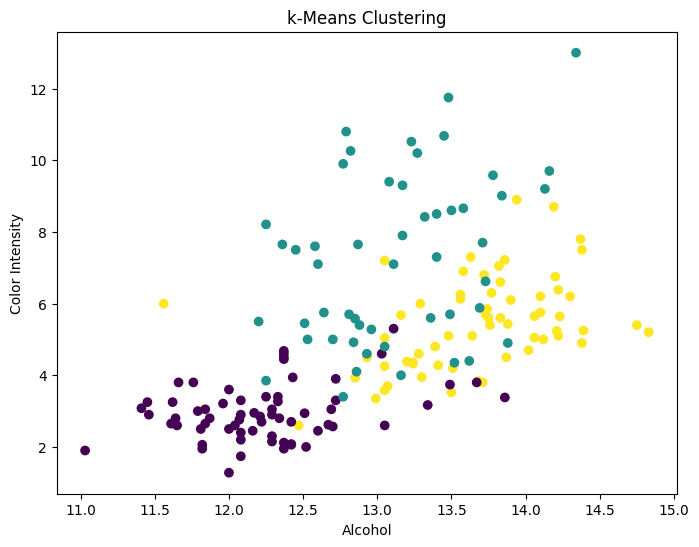

[[-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]]
k-Means clustering successfully grouped wine samples into clusters.


In [1]:
# ==========================================================
# Experiment 12 : k-Means Clustering
# Dataset : Wine Dataset
# ==========================================================

# Step 1 : Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==========================================================
# Step 2 : Load Dataset
# ==========================================================

wine = load_wine()

X = wine.data

# ==========================================================
# Step 3 : Create DataFrame
# ==========================================================

df = pd.DataFrame(
    X,
    columns=wine.feature_names
)

print(df.head())

# ==========================================================
# Step 4 : Dataset Information
# ==========================================================

print(df.info())

print(df.describe())

# ==========================================================
# Step 5 : Check Missing Values
# ==========================================================

print(df.isnull().sum())

# ==========================================================
# Step 6 : Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================================
# Step 7 : Elbow Method
# ==========================================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

# ==========================================================
# Step 8 : Elbow Graph
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

# ==========================================================
# Step 9 : Build k-Means Model
# ==========================================================

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# ==========================================================
# Step 10 : Train Model
# ==========================================================

clusters = model.fit_predict(
    X_scaled
)

# ==========================================================
# Step 11 : Add Cluster Labels
# ==========================================================

df["Cluster"] = clusters

print(df.head())

# ==========================================================
# Step 12 : Cluster Count
# ==========================================================

print(
    df["Cluster"].value_counts()
)

# ==========================================================
# Step 13 : Cluster Visualization
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["alcohol"],
    df["color_intensity"],
    c=df["Cluster"]
)

plt.xlabel("Alcohol")

plt.ylabel("Color Intensity")

plt.title("k-Means Clustering")

plt.show()

# ==========================================================
# Step 14 : Cluster Centers
# ==========================================================

print(
    model.cluster_centers_
)

# ==========================================================
# Step 15 : Conclusion
# ==========================================================

print(
    "k-Means clustering successfully grouped wine samples into clusters."
)